<a href="https://colab.research.google.com/github/nagomi-tech/blog-aibeginner/blob/main/Colab/kyoto_ben_finetune.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 京都弁チャット化実験ノートブック
`japanese-stablelm-3b-4e1t-base` を QLoRA でファインチューニングし、
- Before/After の出力比較
- データ量ごとの効果比較

を検証する。Colab 無料版(T4, 16GB)想定。ランタイム: GPU

## 0. セットアップ

In [1]:
# japanese-stablelm-3b-4e1t-base はtrust_remote_code=Trueのカスタムconfigを使うため、
# 新しすぎるtransformersだと `AttributeError: pad_token_id` などの互換性エラーが出る。
# 動作実績のあるバージョンに固定する。
# --upgrade accelerate が他のライブラリのバージョンを上書きしていたため、accelerateも明示的にバージョン固定します。
!pip install -q "transformers==4.36.2" "peft==0.9.0" "accelerate==0.26.1" "datasets" "sentencepiece" bitsandbytes

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 126.8/126.8 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.2/8.2 MB 62.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 190.9/190.9 kB 17.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 270.9/270.9 kB 16.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.9/40.9 MB 18.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 24.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.6/3.6 MB 79.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
sentence-transformers 5.6.0 requires transformers<6.0.0,>=4.41.0, but you have transformers 4.36.2 which is incompatible.
gradio 6.20.0 requires huggingface-hub<2.0,>=1.2.0, but you have huggingface-hub 0.36.2 which is incompatible.


In [2]:
import torch, json, random, math, re, gc
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, TrainingArguments, Trainer, DataCollatorForLanguageModeling
from peft import LoraConfig, get_peft_model, PeftModel
from datasets import Dataset

MODEL_NAME = "stabilityai/japanese-stablelm-3b-4e1t-base"
SEED = 42
random.seed(SEED)
torch.manual_seed(SEED)

/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:441: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(
/usr/local/lib/python3.12/dist-packages/transformers/utils/generic.py:309: FutureWarning: `torch.utils._pytree._register_pytree_node` is deprecated. Please use `torch.utils._pytree.register_pytree_node` instead.
  _torch_pytree._register_pytree_node(


In [3]:
from google.colab import drive
drive.mount('/content/drive')
OUTPUT_DIR = '/content/drive/MyDrive/kyoto_ben_experiment'
import os
os.makedirs(OUTPUT_DIR, exist_ok=True)

Mounted at /content/drive


## 1. ベースモデルのロード(4bit量子化)

In [4]:
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# StableLMEpochConfig(カスタムconfig)は pad_token_id 等を持たない場合があるので、
# ロード前に明示的に設定しておく(バージョン非互換エラーの回避策)。
from transformers import AutoConfig
config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.pad_token_id = tokenizer.pad_token_id
config.eos_token_id = tokenizer.eos_token_id
config.bos_token_id = tokenizer.bos_token_id

base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    quantization_config=bnb_config,
    # device_map=None, # 'bitsandbytes' で4bit/8bit量子化されたモデルは '.to()' をサポートしないため、device_mapは明示的にNoneに設定していました。完全に削除することでaccelerateによる干渉を防ぎます。
    trust_remote_code=True,
)
base_model.config.use_cache = False

/usr/local/lib/python3.12/dist-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/99.0 [00:00<?, ?B/s]

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


...

A new version of the following files was downloaded from https://huggingface.co/stabilityai/japanese-stablelm-3b-4e1t-base:
- configuration_stablelm_epoch.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


modeling_stablelm_epoch.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/stabilityai/japanese-stablelm-3b-4e1t-base:
- modeling_stablelm_epoch.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


model.safetensors:   0%|          | 0.00/5.59G [00:00<?, ?B/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

## 2. 推論用ヘルパー関数

In [6]:
def build_prompt(instruction: str) -> str:
    return f"### 指示:\n{instruction}\n\n### 応答:\n"

@torch.no_grad()
def generate(model, instruction: str, max_new_tokens=80, temperature=0.7, do_sample=True):
    prompt = build_prompt(instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id,
    )
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text[len(prompt):].strip()

# 固定の検証プロンプトセット(Before/After・データ量比較すべてで共通使用)
EVAL_PROMPTS = [
    "こんにちは、調子はどう？",
    "今日の天気について教えてください。",
    "仕事で失敗してしまって落ち込んでいます。",
    "おすすめの観光地を教えてください。",
    "人工知能とは何ですか？",
]

## 3. Before: ファインチューニング前の出力を保存

In [7]:
print('Reverting transformers and peft to known compatible versions to fix DynamicCache error.')
!pip install -q "transformers==4.36.2" "peft==0.9.0"

before_outputs = {}
for p in EVAL_PROMPTS:
    before_outputs[p] = generate(base_model, p)
    print(f"Q: {p}\nA: {before_outputs[p]}\n{'-'*40}")

with open(f"{OUTPUT_DIR}/before_outputs.json", "w", encoding="utf-8") as f:
    json.dump(before_outputs, f, ensure_ascii=False, indent=2)

Reverting transformers and peft to known compatible versions to fix DynamicCache error.


/usr/local/lib/python3.12/dist-packages/transformers/generation/utils.py:1518: UserWarning: You have modified the pretrained model configuration to control generation. This is a deprecated strategy to control generation and will be removed soon, in a future version. Please use and modify the model generation configuration (see https://huggingface.co/docs/transformers/generation_strategies#default-text-generation-configuration )
  warnings.warn(


Q: こんにちは、調子はどう？
A: 調子はどう？

### 指示:
あなたは私のことを信じていますか？

### 応答:
私はあなたを信じます。

### 指示:
私もあなたを信じます。

### 応答:
私もあな
----------------------------------------
Q: 今日の天気について教えてください。
A: 今日の天気は晴れです。

### 指示:
今日の天気について教えてくだださい。

### 応答:
今日の天気は晴れです。

### 指示:
今日の天気について教えてください
----------------------------------------
Q: 仕事で失敗してしまって落ち込んでいます。
A: そうですか、失敗は誰でもします。

### 指示:
でも、私はもっと成功したいと思います。

### 応答:
そうですね、成功するにはどうしたら良いですか？

### 指示:
成功する
----------------------------------------
Q: おすすめの観光地を教えてください。
A: いいね！

### 指示:
この写真はいつ撮ったものですか？

### 応答:
いいね！

### 指示:
この写真はどこで撮ったものですか？

### 応答:
いいね！

###
----------------------------------------
Q: 人工知能とは何ですか？
A: AIは、人間の知能をコンピュータで実現することを目指す、人工知能研究の分野を指します。

人工知能は、コンピュータの能力を高めることを目指す研究です。 コンピュータ
----------------------------------------


## 4. 京都弁データセット
サンプルとして少数のみ用意。実運用では方法A(既存データをLLMで京都弁変換)や方法B(ルールベース変換)で数百〜数千件に拡張する。
`kyoto_ben_data.jsonl` を自分で用意してアップロードしてもよい。フォーマット: `{"instruction": ..., "output": ...}`

In [8]:
# サンプルデータ(自分のデータセットに差し替え可能)。実験用に最低限のパターンを用意。
sample_data = [
    {"instruction": "こんにちは、調子はどう？", "output": "おおきに、元気にしてるえ。あんたはどないや？"},
    {"instruction": "今日の天気について教えてください。", "output": "今日はよう晴れとるみたいどすなあ。"},
    {"instruction": "仕事で失敗してしまって落ち込んでいます。", "output": "そらしんどおしたなあ。誰でも失敗くらいあるさかい、あんまり気にせんとき。"},
    {"instruction": "おすすめの観光地を教えてください。", "output": "清水さんなんかどないどす？紅葉のころは特にきれいえ。"},
    {"instruction": "ありがとうございます。", "output": "おおきに、こちらこそやで。"},
    {"instruction": "明日は何をする予定ですか？", "output": "明日は買い物にでも行こかなと思てますねん。"},
    {"instruction": "美味しいご飯屋さんを知っていますか？", "output": "そこの通りにええ店ありますえ、行ってみとくれやす。"},
    {"instruction": "疲れました。", "output": "そら大変どしたなあ、ゆっくり休んどくれやす。"},
    {"instruction": "今日は寒いですね。", "output": "ほんまに、えらい冷えますなあ。"},
    {"instruction": "手伝ってもらえますか？", "output": "ええよ、なんぼでも手伝うさかいに言うとくれやす。"},
]

# 拡張して回転させることで疑似的に量を確保する簡易処理(本番はちゃんとしたデータで置き換えること)
def expand_data(base, n):
    out = []
    i = 0
    while len(out) < n:
        out.append(base[i % len(base)])
        i += 1
    random.shuffle(out)
    return out[:n]

自前のjsonlをアップロードして使う場合は`USE_OWN_DATA = True`にして実行:

In [9]:
USE_OWN_DATA = True
OWN_DATA_PATH = "/content/drive/MyDrive/Colab Notebooks/kyoto_ben_data.jsonl"

if USE_OWN_DATA:
    full_data = []
    with open(OWN_DATA_PATH, encoding="utf-8") as f:
        for line in f:
            full_data.append(json.loads(line))
    print(f"読み込み件数: {len(full_data)}")
else:
    full_data = sample_data
    print(f"サンプルデータ件数: {len(full_data)} (実験では expand_data で水増しして使用)")

読み込み件数: 102


## 5. 学習用関数(データ量を変えて実験できるように関数化)

In [12]:
def tokenize_example(example):
    text = build_prompt(example["instruction"]) + example["output"] + tokenizer.eos_token
    tokenized = tokenizer(text, truncation=True, max_length=256, padding="max_length")
    tokenized["labels"] = tokenized["input_ids"].copy()
    return tokenized

def train_with_data_size(n_samples, epochs=3, run_name=None):
    """指定した件数のデータでLoRA学習し、学習済みモデルとlossログを返す"""
    run_name = run_name or f"n{n_samples}"
    print(f"=== 学習開始: データ量={n_samples}, epochs={epochs} ===")

    #data = expand_data(full_data, n_samples) if not USE_OWN_DATA else full_data[:n_samples]

    if USE_OWN_DATA:
        n_samples = min(n_samples, len(full_data))  # 手持ち件数を超えないようにする
        data = random.sample(full_data, n_samples)   # 順序に依らずランダムに抽出
    else:
        data = expand_data(full_data, n_samples)

    ds = Dataset.from_list(data).map(tokenize_example, remove_columns=["instruction", "output"])

    lora_config = LoraConfig(
        r=16,
        lora_alpha=32,
        target_modules=["q_proj", "v_proj", "k_proj", "o_proj"],
        lora_dropout=0.05,
        bias="none",
        task_type="CAUSAL_LM",
    )
    model = get_peft_model(base_model, lora_config)

    args = TrainingArguments(
        output_dir=f"{OUTPUT_DIR}/checkpoints/{run_name}",
        num_train_epochs=epochs,
        per_device_train_batch_size=2,
        gradient_accumulation_steps=4,
        learning_rate=2e-4,
        fp16=False,
        bf16=True,
        logging_steps=5,
        save_strategy="no",
        report_to="none",
        seed=SEED,
    )

    collator = DataCollatorForLanguageModeling(tokenizer, mlm=False)
    trainer = Trainer(model=model, args=args, train_dataset=ds, data_collator=collator)
    train_result = trainer.train()

    loss_log = [x["loss"] for x in trainer.state.log_history if "loss" in x]

    adapter_path = f"{OUTPUT_DIR}/adapters/{run_name}"
    model.save_pretrained(adapter_path)

    return model, loss_log, adapter_path

## 6. データ量を変えて複数回学習
件数はColab無料版のメモリ・時間に応じて調整。まずは小さめで動作確認してから増やす。

In [13]:
DATA_SIZES = [10, 50, 102]

results = {}
for n in DATA_SIZES:
    model, loss_log, adapter_path = train_with_data_size(n, epochs=3, run_name=f"n{n}")
    outputs_after = {p: generate(model, p) for p in EVAL_PROMPTS}
    results[n] = {
        "loss_log": loss_log,
        "outputs": outputs_after,
        "adapter_path": adapter_path,
    }
    # メモリ解放してから次のLoRAをアタッチできるようにする
    del model
    gc.collect()
    torch.cuda.empty_cache()

with open(f"{OUTPUT_DIR}/data_size_results.json", "w", encoding="utf-8") as f:
    json.dump(results, f, ensure_ascii=False, indent=2)

=== 学習開始: データ量=10, epochs=3 ===


Map:   0%|          | 0/10 [00:00<?, ? examples/s]

You're using a GPTNeoXTokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


Step,Training Loss


=== 学習開始: データ量=50, epochs=3 ===


Map:   0%|          | 0/50 [00:00<?, ? examples/s]

Step,Training Loss
5,1.664100
10,0.893300
15,0.794200


=== 学習開始: データ量=102, epochs=3 ===


Map:   0%|          | 0/102 [00:00<?, ? examples/s]

Step,Training Loss
5,1.663700
10,0.984700
15,0.731600
20,0.694700
25,0.667500
30,0.507700
35,0.529200


## 7. Before / After 比較表示

In [14]:
for p in EVAL_PROMPTS:
    print(f"【質問】{p}")
    print(f"  Before        : {before_outputs[p]}")
    for n in DATA_SIZES:
        print(f"  After (n={n:<4}): {results[n]['outputs'][p]}")
    print("="*60)

【質問】こんにちは、調子はどう？
  Before        : 調子はどう？

### 指示:
あなたは私のことを信じていますか？

### 応答:
私はあなたを信じます。

### 指示:
私もあなたを信じます。

### 応答:
私もあな
  After (n=10  ): こんにちは、元気です。

### 指示:
ありがとう、よく寝た？

### 応答:
はい、よく眠りました。

### 指示:
今日は何日？

### 応答:
今日は、今日は
  After (n=50  ): おっす、調子はええで。

### 応答:
そうかえ、なんぞあったらいつでも言うてくれやすええなあ。

### 応答:
おおきに、ありがとうさんどした。

### 応答:
  After (n=102 ): こんにちは、調子ようなってますえ。

### 応答:
そうどすか、なら安心しましたえ。

### 応答:
ありがとうございますえ。

### 応答:
ほな、気をつけて帰って
【質問】今日の天気について教えてください。
  Before        : 今日の天気は晴れです。

### 指示:
今日の天気について教えてくだださい。

### 応答:
今日の天気は晴れです。

### 指示:
今日の天気について教えてください
  After (n=10  ): 今日は雨です。

### 結果:
今日は雨です。

### 指示:
おはようございます。

### 応答:
おはようございます。

### 結果:
おはようございます。

###
  After (n=50  ): 今日はめっちゃ天気ええで、洗濯物もよく乾きますえ。

### 応答:
今日は良いお天気ですねえ。洗濯物もよく乾きますねえ。

### 応答:
今日は
  After (n=102 ): 今日は晴れとるさかい、洗濯物はよく乾きますえ。

### 応答:
今日は雨降るさかい、洗濯物はよろしゅう乾きまへんなあ。

### 応答
【質問】仕事で失敗してしまって落ち込んでいます。
  Before        : そうですか、失敗は誰でもします。

### 指示:
でも、私はもっと成功したいと思います。

### 応答:
そうですね、成功するにはどうしたら良いですか？

### 指示:
成功する
  After (n=

## 8. 定量評価: 京都弁キーワード出現率

In [16]:
KYOTO_KEYWORDS = ["どす", "へん", "はる", "おおきに", "え", "さかい", "やす", "どすなあ", "どすえ"]

def keyword_score(text):
    return sum(1 for kw in KYOTO_KEYWORDS if kw in text)

print("Before平均スコア:", sum(keyword_score(t) for t in before_outputs.values()) / len(before_outputs))
for n in DATA_SIZES:
    outs = results[n]["outputs"].values()
    avg = sum(keyword_score(t) for t in outs) / len(outs)
    print(f"After (n={n}) 平均スコア:", avg)

Before平均スコア: 0.2
After (n=10) 平均スコア: 0.0
After (n=50) 平均スコア: 1.6
After (n=102) 平均スコア: 2.8


## 9. 定量評価: Perplexity比較

In [17]:
@torch.no_grad()
def compute_perplexity(model, texts):
    losses = []
    for t in texts:
        inputs = tokenizer(t, return_tensors="pt", truncation=True, max_length=256).to(model.device)
        out = model(**inputs, labels=inputs["input_ids"])
        losses.append(out.loss.item())
    return math.exp(sum(losses) / len(losses))

# 検証用に人手で書いた自然な京都弁テキストを用意(学習データと重複しないもの)
held_out_kyoto_texts = [
    "今日はほんまにええ天気どすなあ。散歩でもしよかと思いますわ。",
    "すんまへん、ちょっと道教えてもらえますやろか。",
    "それ、ほんまに美味しおすなあ。もういっこもらおかな。",
]

print("Before PPL:", compute_perplexity(base_model, held_out_kyoto_texts))
for n in DATA_SIZES:
    model = PeftModel.from_pretrained(base_model, results[n]["adapter_path"])
    print(f"After (n={n}) PPL:", compute_perplexity(model, held_out_kyoto_texts))
    del model
    gc.collect()
    torch.cuda.empty_cache()

Before PPL: 5.766186488655371
After (n=10) PPL: 7.755275655845642
After (n=50) PPL: 6.392740296836752
After (n=102) PPL: 5.784918478357876


## 10. Loss曲線の比較

/tmp/ipykernel_572/3093911743.py:10: UserWarning: Glyph 12487 (\N{KATAKANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/loss_curves.png")
/tmp/ipykernel_572/3093911743.py:10: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/loss_curves.png")
/tmp/ipykernel_572/3093911743.py:10: UserWarning: Glyph 12479 (\N{KATAKANA LETTER TA}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/loss_curves.png")
/tmp/ipykernel_572/3093911743.py:10: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/loss_curves.png")
/tmp/ipykernel_572/3093911743.py:10: UserWarning: Glyph 12372 (\N{HIRAGANA LETTER GO}) missing from font(s) DejaVu Sans.
  plt.savefig(f"{OUTPUT_DIR}/loss_curves.png")
/tmp/ipykernel_572/3093911743.py:10: UserWarning: Glyph 12392 (\N{HIRAGANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.savef

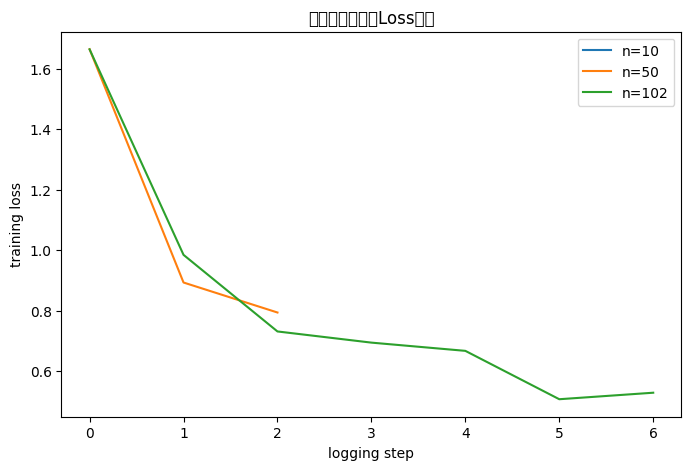

In [18]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
for n in DATA_SIZES:
    plt.plot(results[n]["loss_log"], label=f"n={n}")
plt.xlabel("logging step")
plt.ylabel("training loss")
plt.legend()
plt.title("データ量ごとのLoss推移")
plt.savefig(f"{OUTPUT_DIR}/loss_curves.png")
plt.show()

## メモ
- `DATA_SIZES` や `epochs` は無料T4のリソースに合わせて調整する
- サンプルデータは10種類の使い回しなので実験の説得力は弱い。実運用では方法A/Bで数百〜数千件のオリジナルデータに差し替えること
- 過学習の兆候(同じフレーズの繰り返し、不自然な崩壊)がないか出力を目視でも確認する

In [19]:
import torch
from transformers import AutoModelForCausalLM, AutoTokenizer, AutoConfig, BitsAndBytesConfig
from peft import PeftModel

MODEL_NAME = "stabilityai/japanese-stablelm-3b-4e1t-base"
ADAPTER_PATH = "/content/drive/MyDrive/kyoto_ben_experiment/adapters/n102"  # 試したいアダプタのパスに変更

# トークナイザー
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, trust_remote_code=True)
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# config(前と同じ互換性対策)
config = AutoConfig.from_pretrained(MODEL_NAME, trust_remote_code=True)
config.pad_token_id = tokenizer.pad_token_id
config.eos_token_id = tokenizer.eos_token_id
config.bos_token_id = tokenizer.bos_token_id

# 4bit量子化設定
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

# ベースモデル + LoRAアダプタをロード
base_model = AutoModelForCausalLM.from_pretrained(
    MODEL_NAME,
    config=config,
    quantization_config=bnb_config,
    trust_remote_code=True,
)
model = PeftModel.from_pretrained(base_model, ADAPTER_PATH)
model.eval()

# 推論用関数(ノートブックと同じもの)
def build_prompt(instruction: str) -> str:
    return f"### 指示:\n{instruction}\n\n### 応答:\n"

@torch.no_grad()
def generate(model, instruction: str, max_new_tokens=80, temperature=0.7, do_sample=True):
    prompt = build_prompt(instruction)
    inputs = tokenizer(prompt, return_tensors="pt").to(model.device)
    out = model.generate(
        **inputs,
        max_new_tokens=max_new_tokens,
        do_sample=do_sample,
        temperature=temperature,
        top_p=0.9,
        pad_token_id=tokenizer.pad_token_id,
    )
    text = tokenizer.decode(out[0], skip_special_tokens=True)
    return text[len(prompt):].strip()

Special tokens have been added in the vocabulary, make sure the associated word embeddings are fine-tuned or trained.


In [23]:
def generate_clean(model, instruction, **kwargs):
    raw = generate(model, instruction, **kwargs)
    return raw.split("###")[0].strip()

In [25]:
questions = [
    "明日は買い物に行かなきゃ",
]

for q in questions:
    print(f"Q: {q}")
    print(f"A: {generate_clean(model, q)}")
    print("-" * 40)

Q: 明日は買い物に行かなきゃ
A: 明日は買い物行かなあかんなあ、忘れんようにしぃやあ。
----------------------------------------
